In [1]:
import numpy as np 
import tensorflow as tf
import pandas as pd
from tensorflow.keras import layers, models
import os
import matplotlib.pyplot as plt
import cv2

c:\miniconda\Lib\site-packages\tensorflow\python\keras\engine\training_arrays_v1.py:37: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.5.0)
  from scipy.sparse import issparse  # pylint: disable=g-import-not-at-top


In [2]:

X= []
Y= [] 


def load(phase):
    chemin_dossier_im = './data_hand/'+phase+'/images'
    chemin_dossier_la = './data_hand/'+phase+'/labels'

    for nom_fichier in os.listdir(chemin_dossier_im):
        if nom_fichier.lower().endswith((".jpg", ".jpeg", ".png")):
            chemin_image = os.path.join(chemin_dossier_im, nom_fichier)
                
                
            image = cv2.imread(chemin_image)
            if image is None:
                    continue 
                    
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, (224, 224))
            image = image / 255.0  # Normalisation
                
            nom_txt = os.path.splitext(nom_fichier)[0] + ".txt"
            chemin_txt = os.path.join(chemin_dossier_la, nom_txt)
            
            if os.path.exists(chemin_txt):
                with open(chemin_txt, 'r') as fichier_texte:
                    ligne = fichier_texte.readline().strip()
                    
                    
                if ligne:
                        # ligne de texte (Il y a une main)
                    valeurs = ligne.split()
                        # 
                        # 
                    etiquette = [
                        1.0, 
                        float(valeurs[1]), float(valeurs[2]), 
                        float(valeurs[3]), float(valeurs[4])
                    ]
                else:
                        #  fichier est vide (Image d'arrière-plan / Pas de main)
                        
                    etiquette = [0.0, 0.0, 0.0, 0.0, 0.0]
                        
                    
                X.append(image)
                Y.append(etiquette)
    return X,Y


   # on procède d'abord dans cet ordre parce qu'il est plus rapide d'ajouter à une liste que de modifier la taille dans array
X,Y=load('valid')
X_valid = np.array(X, dtype=np.float32)
Y_valid = np.array(Y, dtype=np.float32)

X,Y = load('train')
X_train = np.array(X, dtype=np.float32)
Y_train = np.array(Y, dtype=np.float32)


In [2]:
def perte_detection_main(y_vraie, y_predite):
    #  La confiance 
    confiance_vraie = y_vraie[:, 0]
    confiance_predite = y_predite[:, 0]

    #  La boîte (les 4 autres neurones : X, Y, W, H)
    boite_vraie = y_vraie[:, 1:]
    boite_predite = y_predite[:, 1:]

    # Erreur de confiance 
    erreur_confiance = tf.keras.losses.MSE(confiance_vraie, confiance_predite)

    # Erreur de la boîte
    erreur_boite = tf.keras.losses.MSE(boite_vraie, boite_predite)

    
    erreur_boite_masquee = erreur_boite * confiance_vraie
    perte_totale = erreur_confiance + (5.0 * erreur_boite_masquee)
    
    return perte_totale

In [13]:
model = models.Sequential([
        layers.InputLayer(input_shape=(224, 224, 3)),
        
        #(32 filtres pour les contours de base)
        layers.Conv2D(32, kernel_size=(3, 3), strides=(2, 2), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        
        #(64 filtres pour les formes simples)
        layers.SeparableConv2D(64, kernel_size=(3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        #(128 filtres pour les concepts complexes)
        layers.SeparableConv2D(128, kernel_size=(3, 3), padding='same', use_bias=False),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        
        # Linéarisation
        layers.GlobalAveragePooling2D(),
        
        #Prédicteur
        layers.Dense(64, activation='relu'),
        # Sortie : 
        layers.Dense(5, activation='sigmoid')
    ])

c:\miniconda\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# arret_urgence = EarlyStopping(
#     monitor='val_loss',  
#     patience=5,          
#     restore_best_weights=True 
# )

# optimiseur = tf.keras.optimizers.Adam(learning_rate=0.001)


# model.compile(
#     optimizer=optimiseur,
#     loss=perte_detection_main, 
#     metrics=['mae']
# )

# historique = model.fit(
#     x=X_train,
#     y=Y_train,
#     validation_data=(X_valid, Y_valid),
#     batch_size=32,       
#     epochs=50,           
#     shuffle=True,
#     callbacks=[arret_urgence] 
# )

# j'ai save l'entrainement dans un fichier, pas besoin de le refaire, a part si vous avez un autre dataset

Epoch 1/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 168s 459ms/step - accuracy: 0.6294 - loss: 0.1094 - val_accuracy: 0.0000e+00 - val_loss: 0.4429
Epoch 2/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 303s 849ms/step - accuracy: 0.6599 - loss: 0.0646 - val_accuracy: 0.5368 - val_loss: 0.0830
Epoch 3/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 368s 1s/step - accuracy: 0.6587 - loss: 0.0564 - val_accuracy: 0.5556 - val_loss: 0.0635
Epoch 4/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 114s 320ms/step - accuracy: 0.6646 - loss: 0.0480 - val_accuracy: 0.4991 - val_loss: 0.0791
Epoch 5/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 111s 312ms/step - accuracy: 0.6663 - loss: 0.0450 - val_accuracy: 0.5960 - val_loss: 0.0533
Epoch 6/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 126s 354ms/step - accuracy: 0.6676 - loss: 0.0423 - val_accuracy: 0.5744 - val_loss: 0.0514
Epoch 7/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 117s 328ms/step - accuracy: 0.6661 - loss: 0.0393 - val_accuracy: 0.5641 - val_loss: 0.0670
Epoch 8/50
356/356 ━━━━━━━━━━━━━━━━━━━━ 108s 303ms/step - accuracy: 0.6696 

In [ ]:
#model.save('modele_final.h5')

NameError: name 'model' is not defined

In [2]:
model = tf.keras.models.load_model('modele_final.h5', compile=False)
print("Modèle chargé avec succès pour la webcam !")

#Image noire
image_test = np.zeros((1, 224, 224, 3), dtype=np.float32)


prediction = model.predict(image_test)
print("Résultat brut de l'IA (Confiance, X, Y, W, H) :")
print(prediction[0])

Modèle chargé avec succès pour la webcam !
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Résultat brut de l'IA (Confiance, X, Y, W, H) :
[0.99642724 0.17189604 0.6545277  0.10377248 0.33583087]


In [3]:
import cv2
import numpy as np

def prediction_boite(image, afficher=True):
    
    hauteur_originale, largeur_originale = image.shape[:2]

    
    img_modele = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #on conforme l'image pour le modèle
    img_modele = cv2.resize(img_modele, (224, 224)) 
    img_modele = img_modele / 255.0
    img_modele = np.expand_dims(img_modele, axis=0)

    
    pred = model.predict(img_modele, verbose=0) # verbose=0 évite de spammer la console, on prédit
    detect, x, y, l, k = pred[0]

   
    if round(float(detect)) == 1:
        #comme les x,yl et k sont entre 0 et 1, on peut trouver les pixels sur l'image de base
        x_min = int(largeur_originale * (x - l/2))
        x_max = int(largeur_originale * (x + l/2))
        y_min = int(hauteur_originale * (y - k/2))
        y_max = int(hauteur_originale * (y + k/2))

        

        # les info de la boite PAR RAPPORT a l'image ORIGINALE
        points_x = np.array([x_min, x_max])
        points_y = np.array([y_min, y_max])
        largeur_pixel = x_max - x_min
        hauteur_pixel = y_max - y_min

        
        if afficher:
            trans = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # B. Dessiner la boîte sur une copie
            image_dessin = trans.copy()
            cv2.rectangle(image_dessin, (x_min, y_min), (x_max, y_max), (0, 255, 0), 3)
            cv2.putText(image_dessin, f"Main: {detect*100:.1f}%", (x_min, max(20, y_min - 10)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            
            #affichage plt de base
            image_rognée = trans[y_min:y_max, x_min:x_max]
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            
            axes[0].imshow(image_dessin)
            axes[0].set_title("Visualition box")
             

            if image_rognée.size > 0:
                axes[1].imshow(image_rognée)
                axes[1].set_title("Input du 2nd modèle")
            else:
                axes[1].text(0.5, 0.5, "Boîte vide", ha='center')

            plt.tight_layout()
            plt.show()

            return points_x, points_y, largeur_pixel, hauteur_pixel, image_rognée
        else :
            trans = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image_rognée = trans[y_min:y_max, x_min:x_max]
            return points_x, points_y, largeur_pixel, hauteur_pixel, image_rognée

    else:
        #print('pas de main')
        return None, None, None, None, None
    


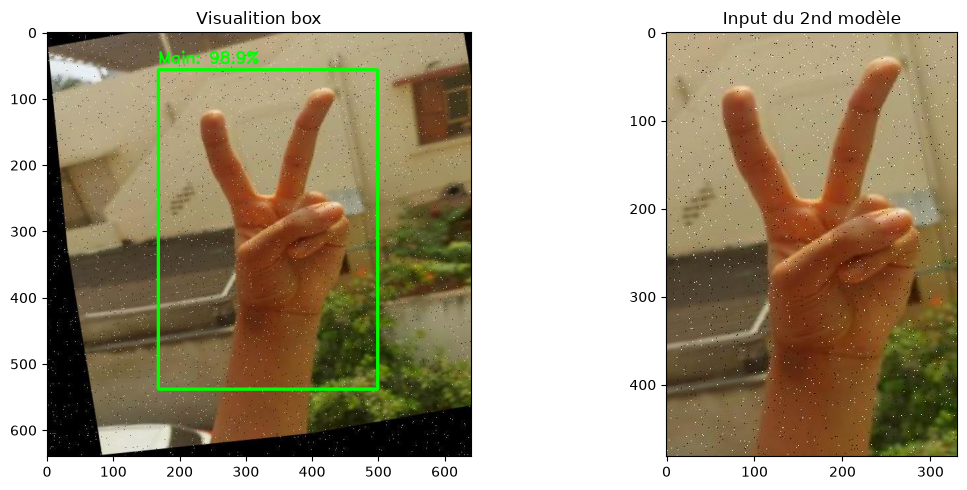

In [4]:
chemin_test = './data_hand/valid/images/V-2-43-_jpg.rf.2056f9cf189b2644b5ab79f6cceaeb08.jpg'
px, py,l,k, input_trans = prediction_boite(cv2.imread(chemin_test,1))


### **Deuxième CNN** 
On va analyser la forme de la main en précision.

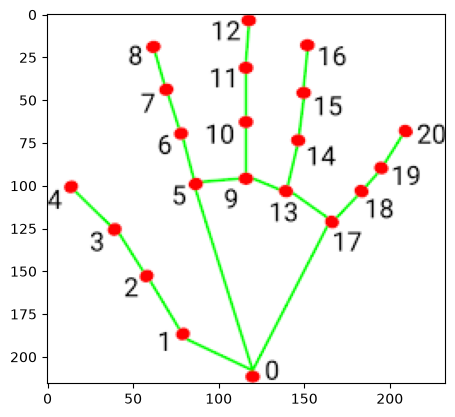

In [5]:
proof = plt.imread('handmark.png')
plt.imshow( proof)

c:\miniconda\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


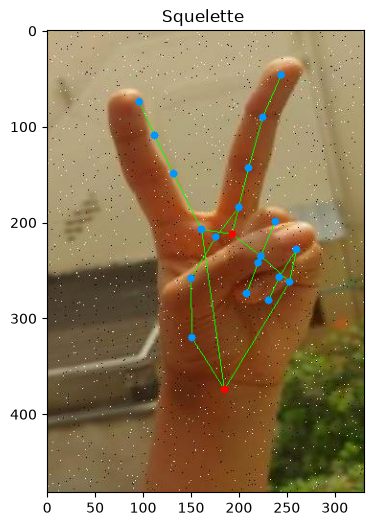

In [6]:
# on chope un modèle tout fait là :
interpreteur = tf.lite.Interpreter(model_path="hand_landmark.tflite")
interpreteur.allocate_tensors()
entree_details = interpreteur.get_input_details()
sortie_details = interpreteur.get_output_details()

#Bon la faut faire confiance au dessin d'au dessus pour dessiner les doigts et reliées les points correctement
CONNEXIONS = [(0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (5, 6), (6, 7), (7, 8), 
             (9, 10), (10, 11), (11, 12), (13, 14), (14, 15), (15, 16), 
             (0, 17), (17, 18), (18, 19), (19, 20), (5, 9), (9, 13), (13, 17)]
                  

def landmark(input_mod, afficher=True):  # commme expliqué sur le commentaire plus bas, ici on trace dans le référentiel de l'image crop

    
    hauteur_crop, largeur_crop = input_mod.shape[:2]
    
   
    img_modele = cv2.resize(input_mod, (256, 256))
    img_modele = img_modele / 255.0
    tenseur_entree = np.expand_dims(img_modele, axis=0).astype(np.float32) #en gros le modèle demande ce genre de données
    

    interpreteur.set_tensor(entree_details[0]['index'], tenseur_entree)
    interpreteur.invoke()
    sortie_brute = interpreteur.get_tensor(sortie_details[0]['index'])[0]
    

    image_dessin = input_mod.copy()
    points = []
    
    
    for i in range(0, 63, 3):
        x_brut = sortie_brute[i]     
        y_brut = sortie_brute[i+1]   
        
        #on adapte par rapport à l'image d'entrée
        x_reel = int((x_brut / 256.0) * largeur_crop)
        y_reel = int((y_brut / 256.0) * hauteur_crop)
        
        points.append((x_reel, y_reel))

    
    # dessin des lignes
    if afficher:
        for depart, arrivee in CONNEXIONS:
            cv2.line(image_dessin, points[depart], points[arrivee], (0, 255, 0), 1) #on prend l'épaisseur la plus fine au cas ou
        #dessins des points
        for i, point in enumerate(points):
            couleur = (255, 0, 0) if i in [0, 9] else (0, 150, 255) #couleur différente pour le poignet et le centre la main
            cv2.circle(image_dessin, point, int(hauteur_crop/100), couleur, -1) #la on adapte le rayon du cercle pour un bon visuel
        plt.figure(figsize=(6, 6))
        plt.imshow(image_dessin)
        plt.title("Squelette ")
        plt.show()
    else :
        pass    
    return points 


points = landmark(input_trans)

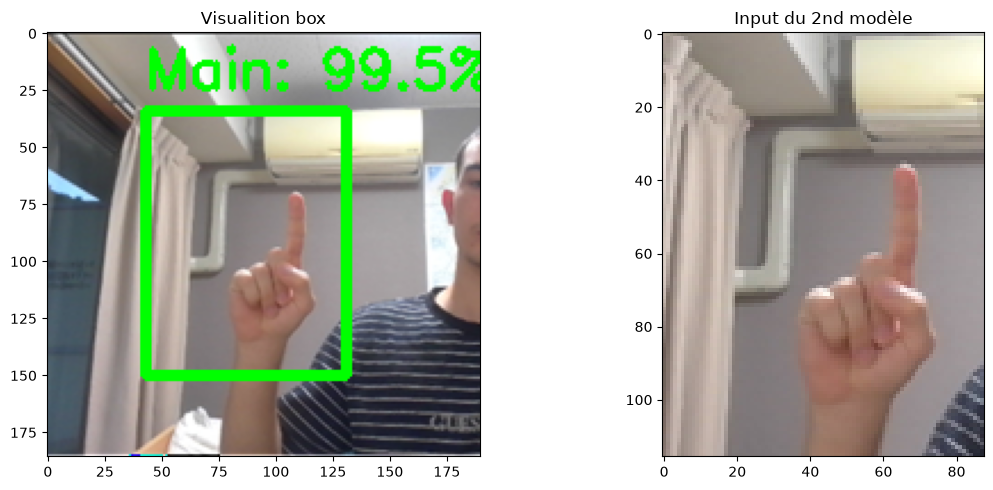

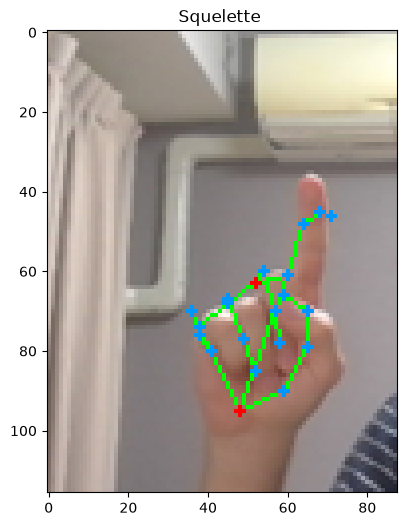

In [7]:
# TEST avec la webcam parce que why not 
landmarks = landmark(prediction_boite(cv2.imread('nao.png', 1))[4])

ptites fonctions pour reconaitre une forme de main, d'après Gemini.

In [ ]:
def norme(a,b):
    return ((a[0]-b[0])**2+(a[1]-b[1])**2)**0.5 

def doigt_est_plie(tip, pip, wrist):
    
    dist_tip_poignet = norme(tip, wrist)
    dist_pip_poignet = norme(pip, wrist)
    
    
    return dist_tip_poignet < dist_pip_poignet

def est_poing_ferme(landmarks):
    poignet = landmarks[0]
    
    # On vérifie les 4 doigts principaux (on exclut souvent le pouce 
    # car sa mécanique de pliure est différente)
    index_plie = doigt_est_plie(landmarks[8], landmarks[6], poignet)
    majeur_plie = doigt_est_plie(landmarks[12], landmarks[10], poignet)
    annulaire_plie = doigt_est_plie(landmarks[16], landmarks[14], poignet)
    auriculaire_plie = doigt_est_plie(landmarks[20], landmarks[18], poignet)
    
    # Si les 4 doigts sont pliés vers le poignet, c'est un poing !
    if index_plie and majeur_plie and annulaire_plie and auriculaire_plie:
        return True
    return False

def est_corne(landmarks):
    poignet = landmarks[0]
    
    index_plie = doigt_est_plie(landmarks[8], landmarks[6], poignet)
    majeur_plie = doigt_est_plie(landmarks[12], landmarks[10], poignet)
    annulaire_plie = doigt_est_plie(landmarks[16], landmarks[14], poignet)
    auriculaire_plie = doigt_est_plie(landmarks[20], landmarks[18], poignet)
    if not index_plie and majeur_plie and annulaire_plie and not auriculaire_plie:
        return True
    else : 
        return False


In [9]:
(doigt_est_plie(landmarks[8], landmarks[6], landmarks[0]),
doigt_est_plie(landmarks[12], landmarks[10], landmarks[0]),
doigt_est_plie(landmarks[16], landmarks[14], landmarks[0]))

(False, True, True)

In [ ]:
import cv2
import numpy as np

# --- 1. OUVERTURE DE LA WEBCAM ---
cap = cv2.VideoCapture(0)

print("Caméra activée ! Appuyez sur la touche 'q' de votre clavier pour quitter proprement.")

while cap.isOpened():
    succes, frame = cap.read()
    if not succes:
        continue

    # B. Effet miroir (plus naturel pour interagir)
    frame = cv2.flip(frame, 1)

    
    points_x, points_y, largeur_boite, hauteur_boite, image_rognee = prediction_boite(frame, afficher=False)

    if points_x is not None:
        x_min, x_max = points_x[0], points_x[1]
        y_min, y_max = points_y[0], points_y[1]

        # On dessine la boîte sur l'image en direct
        cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        

        # Sécurité : on vérifie que la découpe n'est pas vide
        if image_rognee.size > 0:
            
            pontos = landmark(image_rognee, afficher=False) # les points ne seront pas superposés avec la main car landmark est dans le ref de la box
            for depart, arrivee in CONNEXIONS:
                cv2.line(frame, pontos[depart], pontos[arrivee], (0, 255, 0), 1)

            for i, point in enumerate(pontos):
                couleur = (0, 0, 255) if i in [0, 9] else (255, 0, 0)
                cv2.circle(frame, point, 4, couleur, -1)

            if est_poing_ferme(pontos):
                cv2.putText(frame, "poing fermé", (x_max, y_min-10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
            
            if est_corne(pontos):
                cv2.putText(frame, "corne (tah le basket)", (x_max, y_min-10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

                
    else : 
        cv2.putText(frame, "pas de main mskn", (int(frame.shape[0]/2),int(frame.shape[1]/2)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        
        

    # --- 5. AFFICHAGE FINAL ---
    cv2.imshow("Tracking IA Live", frame)

    # --- 6. SÉCURITÉ DE FERMETURE ---
    # L'image s'actualise toutes les 1 milliseconde. 
    # Appuyez sur la touche 'q' du clavier pour sortir de la boucle.
    # ATTENTION : Ne cliquez pas sur la croix rouge de la fenêtre sous Jupyter !
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Nettoyage indispensable pour libérer la caméra
cap.release()
cv2.destroyAllWindows()

Caméra activée ! Appuyez sur la touche 'q' de votre clavier pour quitter proprement.


In [85]:
frame.shape

(480, 640, 3)